Starting MCMC reconstruction of m_b(z)...


100%|██████████| 2000/2000 [02:12<00:00, 15.08it/s]


MCMC finished.

Processing Planck2018+$M_B^\text{SH0ES}$
χ² = 5762.652, p = 0.0000


ValueError: 'yerr' must not contain negative values

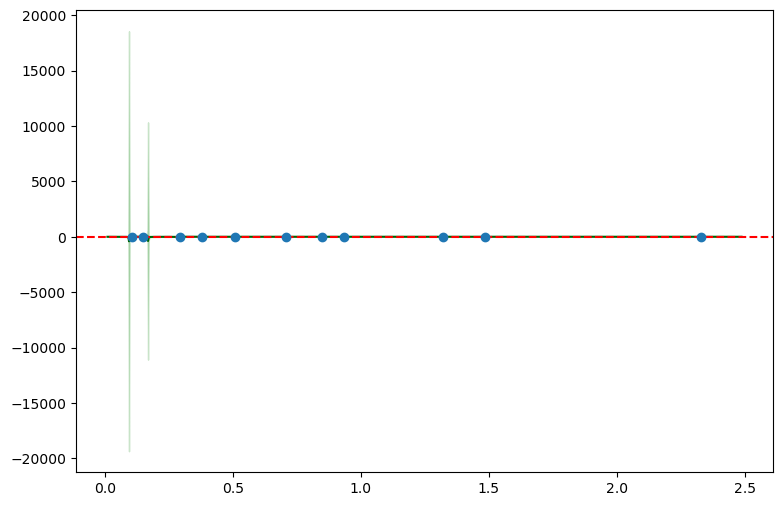

In [3]:
"""
DDR Reconstruction Project
Clean & structured version - functionality preserved.

Sections:
1. Imports & constants
2. Data loading
3. GP + SN reconstruction helpers
4. MCMC functions
5. η(z) reconstruction pipeline
6. Main loop over priors
"""

# ==========================================
# 1. Imports & constants
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import chi2

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C

import emcee


# Speed of light in km/s
C_LIGHT = 299792.458

# Ensure output folder exists
os.makedirs('fig', exist_ok=True)

data_dir = '../data'
output_dir = '../output'


# ==========================================
# 2. Data loading
# ==========================================

def load_bao_data():
    """Load BAO datasets: DV/rd, DM/rd and reconstructed H(z)."""
    z_DV, DV_rd, DV_rd_err = np.loadtxt(os.path.join(data_dir, "Combine_DV_rd.dat"), unpack=True)
    z_DM, DM_rd, DM_rd_err = np.loadtxt(os.path.join(data_dir, "Combine_DM_rd.dat"), unpack=True)
    _, H_DV, H_DV_err = np.loadtxt(os.path.join(output_dir, "Hz_DVreconstruct_results.txt"), unpack=True)
    return (z_DV, DV_rd, DV_rd_err), (z_DM, DM_rd, DM_rd_err), (H_DV, H_DV_err)


def load_sn_data():
    """Load Pantheon+SH0ES SN data."""
    df = pd.read_csv('../data/Pantheon+SH0ES.dat', sep=' ')
    return df['zHD'].values, df['m_b_corr'].values, df['m_b_corr_err_DIAG'].values


def load_sn_covariance(mb_err):
    """Load SN covariance; fallback to diagonal if missing."""
    try:
        with open('../data/Pantheon+SH0ES_STAT+SYS.cov', 'r') as f:
            lines = f.readlines()
        N = int(lines[0].strip())
        cov = np.array([float(x) for x in lines[1:]]).reshape(N, N)
        return np.linalg.inv(cov)

    except FileNotFoundError:
        print("Warning: No covariance found. Using diagonal SN errors!")
        return np.linalg.inv(np.diag(mb_err**2))


# ==========================================
# 3. GP helper: mB_bar(z)
# ==========================================

def compute_mB_bar(z, mB_b_values, z_b_grid):
    """Interpolate mB_bar(z) from sampled bin values."""
    interp = interp1d(np.log(z_b_grid), mB_b_values, fill_value="extrapolate")
    return interp(np.log(z))


# ==========================================
# 4. MCMC functions for mB_bar reconstruction
# ==========================================

def ln_likelihood(mB_b, z, mB, cov_inv, z_b):
    mB_bar = compute_mB_bar(z, mB_b, z_b)
    delta = mB - mB_bar
    return -0.5 * (delta.T @ cov_inv @ delta)


def ln_prior(mB_b):
    # Generic wide bounds
    if np.all((10 < mB_b) & (mB_b < 30)):
        return 0.0
    return -np.inf


def ln_posterior(mB_b, z, mB, cov_inv, z_b):
    lp = ln_prior(mB_b)
    if not np.isfinite(lp):
        return -np.inf
    return lp + ln_likelihood(mB_b, z, mB, cov_inv, z_b)


# ==========================================
# 5. η(z) Reconstruction Core
# ==========================================

def compute_bao_DL(z_DV, DV_rd, DV_rd_err, H_DV, H_DV_err,
                   z_DM, DM_rd, DM_rd_err, rd, rd_err):
    """Compute BAO luminosity distance DL(z) from DV/DM branches."""
    
    # DV branch
    DA_DV_over_rd = DV_rd**1.5 * H_DV**0.5 / (C_LIGHT**0.5 * z_DV**0.5 * (1 + z_DV))
    DA_DV = DA_DV_over_rd * rd
    DA_DV_err = DA_DV * np.sqrt(
        (1.5 * DV_rd_err / DV_rd)**2 +
        (0.5 * H_DV_err / H_DV)**2 +
        (rd_err / rd)**2
    )
    DL_DV = DA_DV * (1 + z_DV)**2

    # DM branch
    DA_DM_over_rd = DM_rd / (1 + z_DM)
    DA_DM = DA_DM_over_rd * rd
    DA_DM_err = DA_DM * np.sqrt(
        (DM_rd_err / DM_rd)**2 +
        (rd_err / rd)**2
    )
    DL_DM = DA_DM * (1 + z_DM)**2

    # Concatenate
    z_bao = np.concatenate([z_DV, z_DM])
    DL_bao = np.concatenate([DL_DV, DL_DM])
    DL_err = np.concatenate([DA_DV_err*(1+z_DV)**2, DA_DM_err*(1+z_DM)**2])

    return z_bao, DL_bao, DL_err


# ==========================================
# 6. Main execution
# ==========================================

def main():

    # Load data
    (z_DV, DV_rd, DV_rd_err), (z_DM, DM_rd, DM_rd_err), (H_DV, H_DV_err) = load_bao_data()
    z_sn, mB, mB_err = load_sn_data()
    cov_inv = load_sn_covariance(mB_err)

    # z grid for MCMC mB_bar parameterization
    z_b = np.logspace(np.log10(0.01), np.log10(max(z_sn)), 36)

    print("Starting MCMC reconstruction of m_b(z)...")

    # ----- Run MCMC -----
    ndim = len(z_b)
    n_walkers = 72
    initial_guess = np.interp(z_b, z_sn, mB) + 0.1 * np.random.randn(n_walkers, ndim)

    sampler = emcee.EnsembleSampler(
        n_walkers, ndim, ln_posterior, args=(z_sn, mB, cov_inv, z_b)
    )
    sampler.run_mcmc(initial_guess, 2000, progress=True)

    print("MCMC finished.")
    samples = sampler.get_chain(discard=200, flat=True)
    mB_opt = np.median(samples, axis=0)

    # GP kernel for BAO DL(z)
    kernel = C(1.0, (1e-3, 1e10)) * Matern(length_scale=0.1, nu=2.5)

    # z for plotting
    z_plot = np.linspace(0.01, max(z_sn)*1.1, 1000).reshape(-1, 1)

    # Priors
    priors = [
        {"name": "Planck2018MB0", "prior_name": r"Planck2018+$M_B^\text{SH0ES}$",
         "Mb": -19.253, "Mb_err": 0.027, "rd": 147.09, "rd_err": 0.26},
        {"name": "Planck2018MB23", "prior_name": r"Planck2018+$M_B^\text{B23}$",
         "Mb": -19.396, "Mb_err": 0.0404, "rd": 147.09, "rd_err": 0.26},
    ]

    # ==========================================
    # Loop over priors
    # ==========================================

    for p in priors:

        print(f"\nProcessing {p['prior_name']}")

        # ----- BAO DL(z) -----
        z_bao, DL_bao, DL_bao_err = compute_bao_DL(
            z_DV, DV_rd, DV_rd_err, H_DV, H_DV_err,
            z_DM, DM_rd, DM_rd_err, p["rd"], p["rd_err"]
        )

        # GP reconstruction of BAO DL(z)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=DL_bao_err**2, n_restarts_optimizer=10)
        gp.fit(z_bao.reshape(-1, 1), DL_bao)

        DL_bao_pred, DL_bao_pred_std = gp.predict(z_plot, return_std=True)

        # ----- Build SN DL(z) ensemble -----
        n_samples = 1000
        idx = np.random.choice(len(samples), n_samples, replace=False)

        DL_sn_samples = []
        Mb_samples = np.random.normal(p["Mb"], p["Mb_err"], n_samples)

        for i in range(n_samples):
            mB_sample = samples[idx[i]]
            MB_value = Mb_samples[i]
            mB_bar_val = compute_mB_bar(z_plot.flatten(), mB_sample, z_b)
            mu = mB_bar_val - MB_value
            DL = 10**((mu - 25)/5)
            DL_sn_samples.append(DL)

        DL_sn_samples = np.array(DL_sn_samples)

        # median + 1σ
        DL_sn = np.median(DL_sn_samples, axis=0)
        DL_sn_err = (np.percentile(DL_sn_samples, 84, axis=0) -
                     np.percentile(DL_sn_samples, 16, axis=0)) / 2

        # η(z) reconstruction
        eta = DL_sn / DL_bao_pred.flatten()
        eta_err = eta * np.sqrt(
            (DL_sn_err / DL_sn)**2 +
            (DL_bao_pred_std / DL_bao_pred.flatten())**2
        )

        # χ² and p-value
        chi2_val = np.sum((eta - 1)**2 / eta_err**2)
        p_val = 1 - chi2.cdf(chi2_val, df=len(eta))

        print(f"χ² = {chi2_val:.3f}, p = {p_val:.4f}")

        # ----------------------------------
        # Plot
        # ----------------------------------
        fig, ax = plt.subplots(figsize=(9, 6))
        zf = z_plot.flatten()

        ax.plot(zf, eta, color='darkgreen', label=r'Reconstructed $\eta(z)$')
        ax.axhline(1, color='red', linestyle='--')

        ax.fill_between(zf, eta - eta_err, eta + eta_err,
                        color='green', alpha=0.2)

        ax.errorbar(z_bao, DL_sn[:len(z_bao)] / DL_bao,
                    yerr=eta_err[:len(z_bao)], fmt='o')

        ax.set_xlabel("Redshift z")
        ax.set_ylabel(r"$\eta(z)$")
        ax.set_title(p["prior_name"])
        ax.grid(True)
        plt.tight_layout()

        plt.savefig(f"fig/eta_{p['name']}.pdf")
        plt.show()

    print("\nAll priors finished.")


# Run
if __name__ == "__main__":
    main()
